In [1]:
#! pip install --upgrade xarray zarr gcsfs cftime nc-time-axis

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
import gcsfs

In [2]:
df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
df_ta = df.query("activity_id=='CMIP' & table_id == 'Amon' & variable_id == 'tas' & experiment_id == 'historical'")
df_ta_ncar = df_ta.query('institution_id == "NCAR"')
gcs = gcsfs.GCSFileSystem(token='anon')

#example stuff from their demo nb
zstore = df_ta_ncar.loc[59875].zstore
mapper = gcs.get_mapper(zstore)
ds = xr.open_zarr(mapper, consolidated=True)

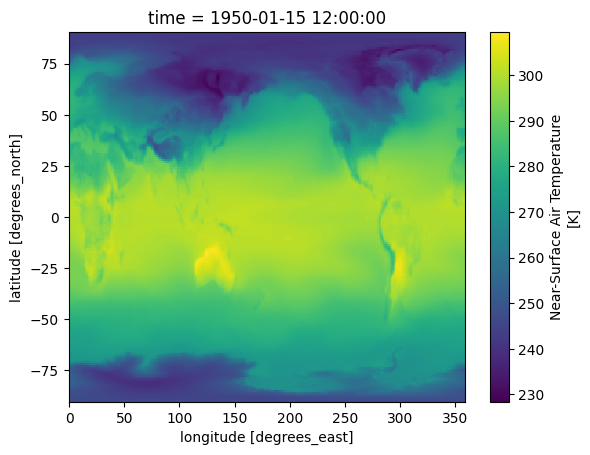

In [4]:
ds.tas.sel(time='1950-01').squeeze().plot()

In [3]:
df_area = df.query("variable_id == 'areacella' & source_id == 'CESM2'")
ds_area = xr.open_zarr(gcs.get_mapper(df_area.zstore.values[0]), consolidated=True)

df_pr = df.query("variable_id == 'pr' & source_id == 'CESM2' & experiment_id == 'historical' & member_id == 'r1i1p1f1'")
ds_pr = xr.open_zarr(gcs.get_mapper(df_pr.zstore.values[0]), consolidated=True)

total_area = ds_area.areacella.sum(dim=['lon', 'lat'])
pr_timeseries = (ds_pr.pr * ds_area.areacella).sum(dim=['lon', 'lat']) / total_area * 86400
pr_seasonal = pr_timeseries.groupby('time.month').mean()
pr_seasonal.load()

def band_mean(lat_min, lat_max):
    area = ds_area.areacella.sel(lat=slice(lat_min, lat_max))
    pr   = ds_pr.pr.sel(lat=slice(lat_min, lat_max)) * 86400
    return (pr * area).sum(['lat','lon']) / area.sum()
tropics   = band_mean(-23.5, 23.5).groupby('time.month').mean().load()
midlat_nh = band_mean(40, 60).groupby('time.month').mean().load()


([<matplotlib.axis.XTick at 0x25d105ec190>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12')])

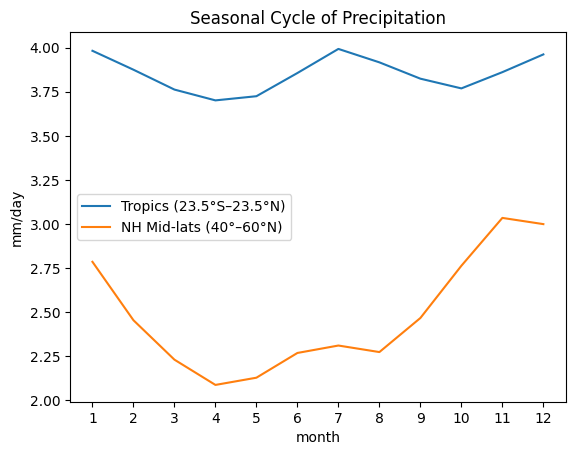

In [6]:
tropics.plot(label='Tropics (23.5°S–23.5°N)')
midlat_nh.plot(label='NH Mid-lats (40°–60°N)')
plt.legend()
plt.title('Seasonal Cycle of Precipitation')
plt.ylabel('mm/day')
plt.xticks(range(1,13), range(1,13))

In [7]:
df_ta_ncar.head(3)

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
56049,CMIP,NCAR,CESM2-WACCM,historical,r2i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2-WACCM/histori...,NaN,20190227
56143,CMIP,NCAR,CESM2-WACCM,historical,r3i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2-WACCM/histori...,NaN,20190227
56326,CMIP,NCAR,CESM2-WACCM,historical,r1i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2-WACCM/histori...,NaN,20190227


In [8]:
df_pointer = df.query("activity_id=='CMIP' & table_id == 'Amon' & variable_id == 'tas' & experiment_id == 'historical' & source_id == 'CESM2' & member_id == 'r1i1p1f1'")
ds_proj = xr.open_zarr(gcs.get_mapper(df_pointer.zstore.values[0]), consolidated=True)
regions = {
    "tropical": (-23.5, 23.5),
    "subtropical": (23.5, 40),
    "temperate": (40, 60),
    "polar": (60, 90)
}
#region classifications from https://content.meteoblue.com/en/research-education/educational-resources/meteoscool/general-climate-zones
#also the baseline is the modern nasa baseline 
items = []

for region, (low, high) in regions.items():
    mask = (np.abs(ds.lat) >= low) & (np.abs(ds.lat) < high)
    spec = ds.tas.where(mask, drop=True)
    spec_mean = spec.mean(dim=['lat', 'lon'])
    yearly = spec_mean.groupby('time.year').mean()
    baseline = spec_mean.sel(time=slice("1951", "1980")).mean(dim="time")
    spec_anom = spec_mean - baseline
    spec_anom_yearly = spec_anom.groupby("time.year").mean()
    for year in yearly['year'].values:
        items.append([
            region,
            int(year),
            float(yearly.sel(year=year)),
            float(spec_anom_yearly.sel(year=year))
        ])
clean_df = pd.DataFrame(items, columns = ['region', 'year', 'mean_temp', 'anomaly'])

    


In [10]:
clean_df.to_csv('temps_by_region.csv')

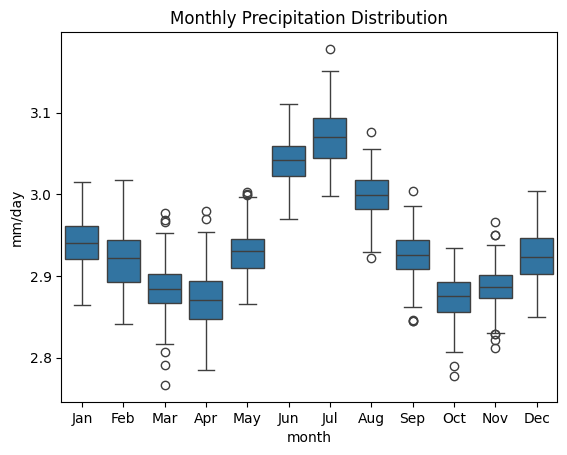

In [6]:
import seaborn as sns
pr_ts = (ds_pr.pr * ds_area.areacella).sum(['lon','lat']) / total_area * 86400
pr_ts.load()

box_df = pd.DataFrame({
    'pr_mm_day': pr_ts.values,
    'month':     pr_ts.time.dt.strftime('%b').values
})
month_order = list('Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec'.split())

sns.boxplot(data=box_df, x='month', y='pr_mm_day', order=month_order)
plt.title('Monthly Precipitation Distribution')
plt.ylabel('mm/day')
plt.show()